# 03. Feature Engineering

`02_eda.ipynb`의 변수 선택 결론을 적용해 모델 입력표를 만든다.

| 단계 | 역할 |
|---|---|
| Data Check (`01`, `01b`) | 원본 구조·자료형·결측·dummy·키를 확인하고 processed 데이터를 추출 |
| EDA (`02`) | 분포·가설·상관관계를 확인하고 유지·제거 근거를 정리 |
| Feature Engineering (`03`) | 초기 관측 구간을 고정하고 변수 생성·제거를 적용해 입력표 저장 |

기존 측정값은 **초기 100사이클 평균**으로 사용하고, EDA에서 유지한 **`log10_dqv_var`**에 더해, 남은 변수의 도메인 조합을 비교해 최종 입력으로 **로그 지표·전체 충전 부담·저항 발열 근사 3개**를 선택한다. 식별자는 `batch`, `cell_id`, 종속변수는 원래 사이클 단위의 `cycle_life`다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"
BATCHES = ["batch1", "batch2", "batch3"]
KEYS = ["batch", "cell_id"]
EARLY_END = 100

all_cells = pd.concat([
    pd.read_csv(DATA / f"{batch}_cells.csv").assign(batch=batch) for batch in BATCHES
], ignore_index=True)
summary = pd.concat([
    pd.read_csv(DATA / f"{batch}_cycle_summary.csv").assign(batch=batch) for batch in BATCHES
], ignore_index=True)
assert not all_cells.duplicated(KEYS).any()
assert not summary.duplicated(KEYS + ["cycle"]).any()
known = all_cells.dropna(subset=["cycle_life"]).copy()
assert np.isfinite(known["cycle_life"]).all() and known["cycle_life"].gt(EARLY_END).all()
print(f"전체 {len(all_cells)}개 중 수명 확인 {len(known)}개 사용")

전체 139개 중 수명 확인 129개 사용


## 기존 정책 변수와 측정값

EDA와 같은 정책 문자열 형식에서 1단계 C-rate, 전환 SOC(%), 2단계 C-rate를 추출한다. 측정값은 cycle 1~100에서 셀별 평균을 구한다. 첫 사이클에서 일곱 측정값이 모두 0인 placeholder만 제외하며, 수명 전체의 평균·마지막 사이클 번호는 사용하지 않는다.

In [2]:
policy_values = known["policy"].str.extract(r"^([\d.]+)C\((\d+)%\)-([\d.]+)C")
policy_values.columns = ["first_c_rate", "switch_soc", "second_c_rate"]
assert policy_values.notna().all().all(), "충전 정책 파싱 실패"
policy_values = policy_values.astype(float)

measurements = ["QCharge", "QDischarge", "IR", "Tavg", "Tmax", "Tmin", "chargetime"]
placeholder = summary["cycle"].eq(1) & summary[measurements].eq(0).all(axis=1)
early = summary.loc[summary["cycle"].between(1, EARLY_END) & ~placeholder]
early_means = early.groupby(KEYS)[measurements].mean().add_prefix("mean_").reset_index()

candidate_features = pd.concat([known[KEYS + ["cycle_life"]], policy_values], axis=1)
candidate_features = candidate_features.merge(early_means, on=KEYS, validate="one_to_one")
assert len(candidate_features) == len(known)
display(candidate_features.head())

,batch,cell_id,cycle_life,first_c_rate,switch_soc,second_c_rate,mean_QCharge,mean_QDischarge,mean_IR,mean_Tavg,mean_Tmax,mean_Tmin,mean_chargetime
0,batch1,1,1190.0,3.6,80.0,3.6,1.080434,1.080597,0.016643,31.603747,35.376748,29.345269,13.384231
1,batch1,2,1179.0,3.6,80.0,3.6,1.081092,1.081247,0.016751,31.330314,34.160655,29.561504,13.374696
2,batch1,3,1177.0,3.6,80.0,3.6,1.085146,1.085371,0.016600,31.479584,34.544644,29.640759,13.378886
3,batch1,4,1226.0,4.0,80.0,4.0,1.084546,1.084949,0.016146,29.942199,30.662263,29.385642,12.053277
4,batch1,5,1227.0,4.0,80.0,4.0,1.082700,1.082844,0.016501,31.448884,34.382516,29.487975,12.053314


## 로그 지표 생성

EDA에서 유지한 `log10_dqv_var = log10(var(Q100(V) − Q10(V)))`를 생성한다. 각 셀의 저장된 cycle 번호로 10·100사이클을 찾아 같은 전압축의 곡선을 비교한다. 분산은 EDA와 동일하게 `np.var`의 기본값(ddof=0)을 사용한다.

In [3]:
voltage = pd.read_csv(DATA / "batch1_vdlin.csv")["Vdlin"].to_numpy()
assert len(voltage) == 1000 and np.all(np.diff(voltage) < 0)
log_rows = []
for batch in BATCHES:
    batch_voltage = pd.read_csv(DATA / f"{batch}_vdlin.csv")["Vdlin"].to_numpy()
    assert np.allclose(batch_voltage, voltage, rtol=0, atol=1e-12)
    with np.load(DATA / f"{batch}_cycle_profiles.npz", allow_pickle=False) as archive:
        for cell_id in known.loc[known["batch"].eq(batch), "cell_id"]:
            cycles = archive[f"cell_{cell_id}_cycle"]
            indices = [np.flatnonzero(cycles == cycle) for cycle in [10, EARLY_END]]
            assert all(len(index) == 1 for index in indices), f"{batch}/{cell_id}: 초기 cycle 누락"
            q = archive[f"cell_{cell_id}_qdlin"]
            assert q.shape == (len(cycles), len(voltage))
            q10, q100 = q[indices[0][0]], q[indices[1][0]]
            assert np.isfinite([q10, q100]).all()
            variance = np.var(q100 - q10)
            assert variance > 0, f"{batch}/{cell_id}: 로그를 적용할 수 없는 분산"
            log_rows.append({"batch": batch, "cell_id": cell_id,
                             "log10_dqv_var": np.log10(variance)})
            del q

candidate_features = candidate_features.merge(pd.DataFrame(log_rows), on=KEYS, validate="one_to_one")
assert len(candidate_features) == len(known)
assert np.isfinite(candidate_features.drop(columns=KEYS).to_numpy()).all()

## EDA의 중복 제거 결론 적용

독립변수끼리 |Pearson r| ≥ 0.8인 쌍은 평균 온도–최대 온도(**0.880**), 평균 온도–최소 온도(**0.859**)다. 온도 변수는 대표 하나를 남긴다.

| 변수 | 결정 | EDA 근거 |
|---|---|---|
| `mean_Tmin` | 유지 | 온도 변수 중 수명과의 상관이 가장 큼: Pearson **+0.332**, Spearman **+0.303** |
| `mean_Tavg` | 제거 | `mean_Tmin`과 r=**0.859**로 중복되며 수명과의 상관은 더 작음: Pearson **+0.238**, Spearman **+0.190** |
| `mean_Tmax` | 제거 | `mean_Tavg`와 r=**0.880**인 온도 묶음에서 수명과의 상관이 가장 약함: Pearson **−0.017**, Spearman **−0.011** |

`mean_Tmax`–`mean_Tmin`의 r는 **0.574**이므로, 최대 온도 제거에는 수명과의 상관이 약하다는 근거도 사용한다. 다른 변수는 이번 중복 제거 대상이 아니다. 초기 Q 급변·knee는 최종 입력표에 넣지 않는다. 아래에서 남은 변수로 만들 수 있는 충전 부담 등의 조합을 별도로 검토한다.

In [4]:
dropped_features = ["mean_Tavg", "mean_Tmax"]
base_features = ["first_c_rate", "switch_soc", "second_c_rate", "mean_QCharge",
                 "mean_QDischarge", "mean_IR", "mean_Tmin", "mean_chargetime", "log10_dqv_var"]
base_data = candidate_features.drop(columns=dropped_features).sort_values(KEYS).reset_index(drop=True)
base_data = base_data[KEYS + base_features + ["cycle_life"]]
assert len(base_data) == len(known) and not base_data.duplicated(KEYS).any()
assert np.isfinite(base_data[base_features + ["cycle_life"]].to_numpy()).all()
assert not set(dropped_features) & set(base_data.columns)
remaining_corr = base_data[base_features].corr().to_numpy()
assert np.abs(remaining_corr[np.triu_indices(len(base_features), k=1)]).max() < 0.8
display(base_data.head())

,batch,cell_id,first_c_rate,switch_soc,second_c_rate,mean_QCharge,mean_QDischarge,mean_IR,mean_Tmin,mean_chargetime,log10_dqv_var,cycle_life
0,batch1,1,3.6,80.0,3.6,1.080434,1.080597,0.016643,29.345269,13.384231,-5.014861,1190.0
1,batch1,2,3.6,80.0,3.6,1.081092,1.081247,0.016751,29.561504,13.374696,-5.013960,1179.0
2,batch1,3,3.6,80.0,3.6,1.085146,1.085371,0.016600,29.640759,13.378886,-4.737000,1177.0
3,batch1,4,4.0,80.0,4.0,1.084546,1.084949,0.016146,29.385642,12.053277,-4.442613,1226.0
4,batch1,5,4.0,80.0,4.0,1.082700,1.082844,0.016501,29.487975,12.053314,-4.647744,1227.0


## 남은 변수의 도메인 조합

충전속도 한 값만으로는 **어느 SOC 구간에서, 얼마나 많은 충전량에 그 속도를 적용했는지**를 표현하기 어렵다. 이 데이터의 정책은 $C_1$으로 전환 SOC까지, $C_2$로 80%까지 충전하며 이후 1C 충전은 공통이다. 공칭 용량은 $Q_n=1.1$ Ah다. 아래에서 $s=\text{switch\_soc}/100$으로 둔다. [Severson et al. (2019), Methods](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)

| 후보 | 생성식 | 도메인 관점에서 확인할 관계 |
|---|---|---|
| `charge_stress` | $C_1s+C_2(0.8-s)$ | 단계별 전류 크기와 충전 SOC 폭을 함께 반영. 같은 충전시간이어도 전류를 배분하는 방식에 따라 전기적 부담이 달라질 수 있음 |
| `stage2_stress` | $C_2(0.8-s)$ | 2단계 충전속도와 그 속도로 충전하는 양을 함께 표현. 2단계가 끝나는 80% SOC까지의 부담을 구분 |
| `equivalent_c_rate` | $0.8/[s/C_1+(0.8-s)/C_2]$ | 0~80% 이상적 정전류 충전시간으로부터 구한 평균 충전속도. 전체 속도만으로 충분한지 비교 |
| `charge_discharge_ratio` | $\overline Q_{dis}/\overline Q_{chg}$ | 넣은 전하 대비 회수한 전하의 비율. 부반응·리튬 손실과 연결되는 쿨롱 효율의 관점에서 후보 검토 |
| `joule_heat_proxy` | $\overline{IR}\,Q_n^2\,\text{charge\_stress}$ | 전류와 내부저항을 결합한 0~80% 저항 발열 에너지 근사(Wh) |
| `thermal_charge_interaction` | $\text{charge\_stress}(\overline T_{min}-30)$ | 30°C 시험 챔버를 기준으로 한 최소 표면온도 편차와 충전 부담의 교호작용 |

**전체 충전 부담을 이렇게 정의한 이유:** 정전류 단계에서 $I=C Q_n$, $\Delta t=\Delta SOC/C$이므로 저항이 일정하다고 근사하면 $\int I^2R\,dt=RQ_n^2 C\,\Delta SOC$이다. 두 단계의 항을 합하면 `charge_stress`가 된다. 이는 전류의 제곱을 시간에 대해 적분한 양에 비례하는 지표이며, 저항을 곱한 `joule_heat_proxy`까지 별도로 비교한다. 실제 총발열에는 다른 성분도 있고 펄스 측정 IR은 구간 전체의 저항을 대표하는 근사다. [Measuring Irreversible Heat Generation (2022), Eq. 10](https://doi.org/10.1149/1945-7111/ac5ada)

**수명과 연결되는 물리적 이유:** 큰 충전전류는 분극과 물질 전달 부담을 높여 흑연 음극의 리튬 도금 및 용량 감소와 연결될 수 있다. 따라서 전류와 충전 구간을 묶는 조합을 우선 검토한다. `stage2_stress`는 그 단계의 SOC 폭을 반영하는 대리지표이며, 모든 셀에서 동일한 고SOC 구간을 적분한 값은 아니다. [Onboard early detection and mitigation of lithium plating (2022)](https://www.nature.com/articles/s41467-022-33486-4)

**용량비와 온도 조합의 해석:** 쿨롱 효율은 수명과 연결될 수 있지만 초기에는 1을 넘는 사례도 있다. 여기의 비율은 초기 100사이클 용량 평균의 비이며 정밀한 손실량으로 단정하지 않는다. 최소 표면온도도 실제 충전중 온도나 주변온도와 같다고 가정하지 않고, 교호작용 후보로만 비교한다. [Gyenes et al. (2015)](https://doi.org/10.1149/2.0191503JES)

모든 후보는 기존 초기 100사이클 측정값과 충전 정책만으로 계산한다. 새로운 관측정보가 추가되지는 않지만, 선형 모델에서 전류와 구간의 조합을 직접 사용할 수 있는 표현을 만든다.

Pearson                      Spearman         \
group                          All batch1 batch2 batch3      All batch1   
feature                                                                   
charge_stress               -0.356 -0.892 -0.210 -0.449   -0.345 -0.866   
stage2_stress               -0.243 -0.223 -0.145 -0.546   -0.207 -0.182   
equivalent_c_rate           -0.223 -0.737  0.334 -0.018   -0.146 -0.634   
charge_discharge_ratio       0.088  0.124  0.192 -0.111   -0.284  0.015   
joule_heat_proxy            -0.526 -0.824 -0.632  0.012   -0.626 -0.768   
thermal_charge_interaction   0.335 -0.387  0.537 -0.005    0.295 -0.262   

                                          
group                      batch2 batch3  
feature                                   
charge_stress              -0.180 -0.528  
stage2_stress              -0.328 -0.509  
equivalent_c_rate           0.321 -0.132  
charge_discharge_ratio      0.201 -0.034  
joule_heat_proxy           -0.348  0.083  
thermal_charge_interaction  0.311  0.105

발열 후보 표본 수: [{'group': 'All', 'n': 123}, {'group': 'batch1', 'n': 46}, {'group': 'batch2', 'n': 33}, {'group': 'batch3', 'n': 44}]
충·방전 용량비 > 1인 셀: 111


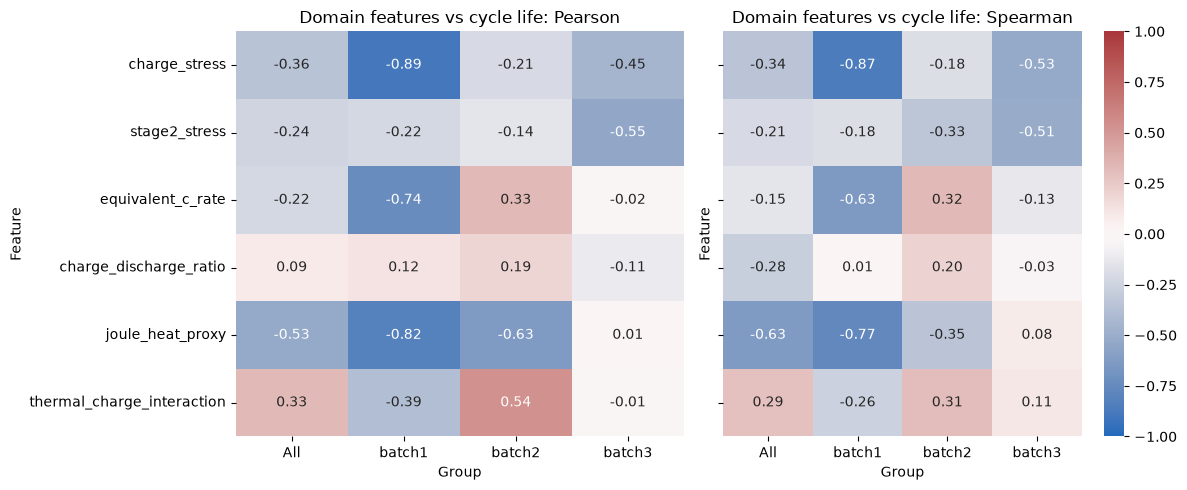

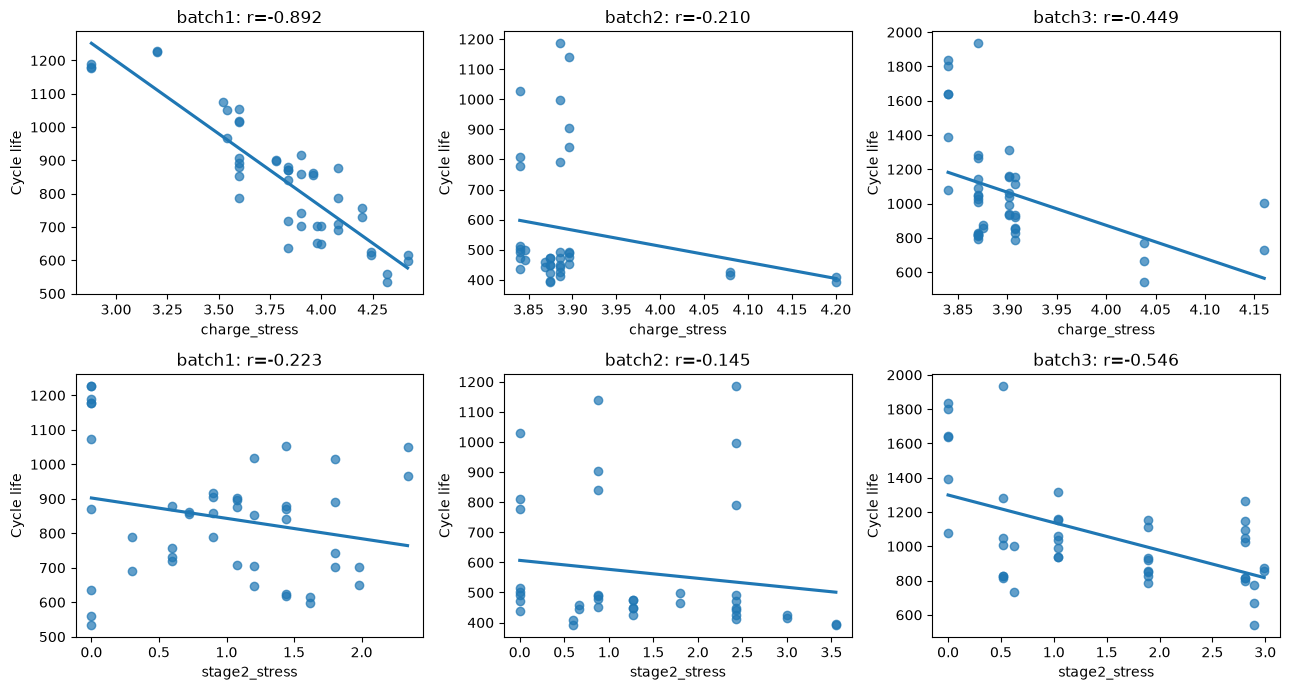

,variable_1,variable_2,Pearson_r
0,switch_soc,stage2_stress,-0.965
1,mean_Tmin,thermal_charge_interaction,0.999


In [5]:
domain_data = base_data.copy()
s = domain_data["switch_soc"] / 100
c1, c2 = domain_data["first_c_rate"], domain_data["second_c_rate"]
assert s.between(0, 0.8).all() and c1.gt(0).all() and c2.gt(0).all()
assert domain_data["mean_QCharge"].gt(0).all()

domain_data["charge_stress"] = c1 * s + c2 * (0.8 - s)
domain_data["stage2_stress"] = c2 * (0.8 - s)
domain_data["equivalent_c_rate"] = 0.8 / (s / c1 + (0.8 - s) / c2)
domain_data["charge_discharge_ratio"] = domain_data["mean_QDischarge"] / domain_data["mean_QCharge"]
# IR=0인 6개 셀은 발열이 없다는 뜻으로 해석하지 않고 이 후보의 비교에서만 제외한다.
positive_ir = domain_data["mean_IR"].where(domain_data["mean_IR"].gt(0))
domain_data["joule_heat_proxy"] = positive_ir * 1.1**2 * domain_data["charge_stress"]
domain_data["thermal_charge_interaction"] = domain_data["charge_stress"] * (domain_data["mean_Tmin"] - 30)
domain_features = ["charge_stress", "stage2_stress", "equivalent_c_rate",
                   "charge_discharge_ratio", "joule_heat_proxy", "thermal_charge_interaction"]

# 단일 충전속도 및 80%에서 전환하는 경계에서 생성식이 맞는지 확인한다.
toy_s = np.array([0.2, 0.8])
assert np.allclose(4 * toy_s + 4 * (0.8 - toy_s), 3.2)
assert np.isclose((4 * (0.8 - toy_s))[-1], 0)
assert np.allclose(0.8 / (toy_s / 4 + (0.8 - toy_s) / 4), 4)
assert np.isfinite(domain_data[domain_features].drop(columns="joule_heat_proxy").to_numpy()).all()

rows = []
for group_name, group in [("All", domain_data), *list(domain_data.groupby("batch"))]:
    for feature in domain_features:
        valid = group[[feature, "cycle_life"]].dropna()
        rows.append({"group": group_name, "feature": feature, "n": len(valid),
                     "Pearson_r": valid[feature].corr(valid["cycle_life"]),
                     "Spearman_rho": valid[feature].corr(valid["cycle_life"], method="spearman")})
domain_stats = pd.DataFrame(rows)
group_order = ["All", *BATCHES]
pearson = domain_stats.pivot(index="feature", columns="group", values="Pearson_r").reindex(
    index=domain_features, columns=group_order)
spearman = domain_stats.pivot(index="feature", columns="group", values="Spearman_rho").reindex(
    index=domain_features, columns=group_order)
display(pd.concat({"Pearson": pearson, "Spearman": spearman}, axis=1).round(3))
print("발열 후보 표본 수:", domain_stats.loc[domain_stats["feature"].eq("joule_heat_proxy"),
                                         ["group", "n"]].to_dict("records"))
print("충·방전 용량비 > 1인 셀:", domain_data["charge_discharge_ratio"].gt(1).sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, matrix, label in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
                cbar=ax is axes[1], ax=ax)
    ax.set(title=f"Domain features vs cycle life: {label}", xlabel="Group", ylabel="Feature")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for row, feature in enumerate(["charge_stress", "stage2_stress"]):
    for col, batch in enumerate(BATCHES):
        group = domain_data.loc[domain_data["batch"].eq(batch)]
        sns.regplot(data=group, x=feature, y="cycle_life", ci=None,
                    scatter_kws={"alpha": 0.7}, ax=axes[row, col])
        axes[row, col].set(title=f"{batch}: r={pearson.loc[feature, batch]:.3f}",
                           xlabel=feature, ylabel="Cycle life")
plt.tight_layout()
plt.show()

# 새 후보가 기존 변수와 거의 같은 표현인지도 함께 확인한다.
joint_corr = domain_data[base_features + domain_features].corr()
pair_rows = []
for i, left in enumerate(joint_corr.columns):
    for right in joint_corr.columns[i + 1:]:
        value = joint_corr.loc[left, right]
        if abs(value) >= 0.8:
            pair_rows.append({"variable_1": left, "variable_2": right, "Pearson_r": value})
domain_strong_pairs = pd.DataFrame(pair_rows)
display(domain_strong_pairs.round(3))

## 도메인 조합의 확인 결과와 선택

| 후보 | 전체 Pearson r | 배치1 / 배치2 / 배치3 r | 판단 |
|---|---:|---|---|
| 전체 충전 부담 | **−0.356** | **−0.892 / −0.210 / −0.449** | 유지: 세 배치 모두 음의 관계, 배치1에서 특히 뚜렷함 |
| 2단계 충전 부담 | **−0.243** | **−0.223 / −0.145 / −0.546** | 대안 후보: 배치3에서 더 뚜렷하지만 이번 3변수 구성에는 포함하지 않음 |
| 이상적 평균 충전속도 | −0.223 | −0.737 / +0.334 / −0.018 | 보류: 배치별 방향이 다르며 전체 속도만으로 구간별 부담을 충분히 표현하지 못함 |
| 충·방전 용량비 | +0.088 | +0.124 / +0.192 / −0.111 | 보류: 수명 관계가 약함. 129개 중 111개가 1을 넘어 손실량으로 직접 해석하기 어려움 |
| 저항 발열 근사 | −0.526 | −0.824 / −0.632 / +0.012 | 유지: 전류·충전 구간·저항을 결합한 물리적 대리지표. 123개에서 비교하며 배치1·2에서 관계가 있고 배치3에서는 거의 없음 |
| 온도·충전 부담 교호작용 | +0.335 | −0.387 / +0.537 / −0.005 | 제외: 배치별 방향이 다르고 기존 `mean_Tmin`과 r=**0.999**로 거의 겹침 |

**전체 충전 부담**은 1단계 충전속도만 사용할 때의 배치1 r=−0.580보다 더 뚜렷한 관계를 보였다. **2단계 충전 부담**은 2단계 속도 단독의 배치3 r=−0.043보다 더 뚜렷했다. 따라서 충전속도와 그 속도를 적용한 SOC 폭을 묶는 표현이 이번 데이터에서 수명 관계를 더 잘 드러냈다. 예를 들어 전환 SOC가 80%인 정책은 2단계 충전량이 0이어서 `stage2_stress=0`이 된다. 정책에 적힌 2단계 속도 값만 비교하면 이 차이를 놓치지만, 구간을 곱하면 실제로 적용한 충전량을 반영한다.

### 최종 선택: 독립변수 3개

| 입력 변수 | 반영하는 정보 |
|---|---|
| `log10_dqv_var` | 초기 전압별 방전곡선 변화의 불균일성: 열화 반응을 관측한 지표 |
| `charge_stress` | 충전속도와 적용 SOC 구간: 정책 자체의 전기적 부담 |
| `joule_heat_proxy` | 충전 부담에 내부저항을 결합: 셀 상태를 고려한 저항 발열 근사 |

저항 발열 근사는 `mean_IR × 1.1² × charge_stress`이므로 전체 충전 부담과 같은 식의 일부를 공유한다. 두 지표 간 상관과 로그 지표와의 중복은 아래에서 확인하고, 저항 정보가 추가적인 예측력을 주는지는 모델링에서 비교한다.

모델에 입력 변수 3개를 사용하는 것은 가능하다. 예를 들어 선형회귀는 세 계수와 절편을 학습한다. 변수 수 자체보다 평가 데이터에서의 예측 오차와 각 지표의 추가 설명력을 확인한다. [선형회귀 공식 문서](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares)

초기 IR 평균이 0인 6개 셀에서는 저항 발열 근사를 계산하지 않는다. 이번 3지표 입력표는 **세 값이 모두 있는 123개 셀**로 만들며, 제외 셀은 아래에 표시한다. 원본과 EDA의 129개 셀은 그대로 보존한다.

In [6]:
feature_columns = ["log10_dqv_var", "charge_stress", "joule_heat_proxy"]
missing = domain_data[feature_columns].isna().any(axis=1)
excluded = domain_data.loc[missing, KEYS + ["mean_IR", "cycle_life"]]
model_data = domain_data.loc[~missing, KEYS + feature_columns + ["cycle_life"]].reset_index(drop=True)
assert len(model_data) + len(excluded) == len(known)
assert not model_data.duplicated(KEYS).any()
assert np.isfinite(model_data[feature_columns + ["cycle_life"]].to_numpy()).all()
assert len(feature_columns) == 3
assert excluded["mean_IR"].eq(0).all()

final_corr = model_data[feature_columns].corr()
display(final_corr.round(3))
assert np.abs(final_corr.to_numpy()[np.triu_indices(3, k=1)]).max() < 0.8
print(f"발열 근사 결측으로 제외한 셀: {len(excluded)}개")
display(excluded.reset_index(drop=True))

output_path = DATA / "battery_features.csv"
model_data.to_csv(output_path, index=False)
saved = pd.read_csv(output_path)
pd.testing.assert_frame_equal(saved, model_data, check_dtype=False)
print(f"저장: {output_path}")
print(f"셀 {len(model_data)}개 / 독립변수 {len(feature_columns)}개")
display(model_data.groupby("batch").size().rename("n_cells"))
display(model_data.head())

,log10_dqv_var,charge_stress,joule_heat_proxy
log10_dqv_var,1.000,0.558,0.685
charge_stress,0.558,1.000,0.726
joule_heat_proxy,0.685,0.726,1.000


발열 근사 결측으로 제외한 셀: 6개


,batch,cell_id,mean_IR,cycle_life
0,batch2,42,0.0,442.0
1,batch2,43,0.0,474.0
2,batch2,44,0.0,1029.0
3,batch2,45,0.0,841.0
4,batch2,46,0.0,997.0
5,batch2,47,0.0,503.0


저장: /Users/u102/workspace_public/021_Data_Analytics_Mini_Projcet/Data_Analytics_MiniProject_Skala/data/processed/battery_features.csv
셀 123개 / 독립변수 3개


batch
batch1    46
batch2    33
batch3    44
Name: n_cells, dtype: int64

,batch,cell_id,log10_dqv_var,charge_stress,joule_heat_proxy,cycle_life
0,batch1,1,-5.014861,2.88,0.057999,1190.0
1,batch1,2,-5.013960,2.88,0.058373,1179.0
2,batch1,3,-4.737000,2.88,0.057846,1177.0
3,batch1,4,-4.442613,3.20,0.062518,1226.0
4,batch1,5,-4.647744,3.20,0.063890,1227.0


## 모델링으로 전달

`data/processed/battery_features.csv`에 **123개 셀, 독립변수 3개**를 저장한다. 입력은 `log10_dqv_var`, `charge_stress`, `joule_heat_proxy`이며 종속변수는 `cycle_life`다. `batch`, `cell_id`는 식별·배치 구분용으로 모델 입력에서 제외한다.

DAY 2의 `04_modeling.ipynb`에서는 이 입력표 중 **Batch1 46개·Batch2 33개, 총 79개 셀**을 사용한다. Batch1은 충전 프로토콜 기준으로 학습 35개·Hold-out 11개로 나누고, 같은 분할에서 로그 지표 단독 → 로그+전체 충전 부담 → 세 지표의 성능을 비교한다. 스케일링과 Ridge α 선택은 Batch1 학습 데이터에서 수행하며, Batch2는 배치 간 테스트로 평가한다. **Batch3은 이번 모델링·평가에서 제외한다.**